# Colored Signed Distance Functions

Creating CSDFs for easy interchangable data

In [9]:
%load_ext autoreload
%autoreload 2
from context import generationtools as gnt
import trimesh

meshPath = r"../data\completionchair\CompletionChair.obj"
voxelResolution = 64 # The resolution of the voxelgrid

# load the mesh
mesh  = trimesh.load(meshPath, force='mesh')
meshName = meshPath.split('\\')[-1][:-4]
savePath = r"../data/voxelEditing/" + meshName
# convert to SDF
sdf,normalized_mesh = gnt.mesh_to_sdf_tensor(gnt.as_mesh(mesh), voxelResolution, recenter=True, scaledownFactor=0.85)
# Get the colors
voxel_grid = gnt.create_voxel_grid(voxelResolution, True)
colors = gnt.get_point_colors_trimesh(normalized_mesh, voxel_grid.reshape(-1,3)).reshape(voxelResolution,voxelResolution,voxelResolution,4)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# OPTIONAL Evaluate the colors in the SDF mesh
marching_mesh = gnt.sdf_to_mesh(sdf, 1/voxelResolution, True)
# Interpolate vertex colors
vertex_colors = gnt.interpolate_vertex_colors(marching_mesh.vertices, colors)
# Create a Trimesh object with vertex colors
new_mesh = trimesh.Trimesh(vertices=marching_mesh.vertices, faces=marching_mesh.faces, vertex_colors=vertex_colors[:,:3])
new_mesh.export(savePath + "_source_" + str(voxelResolution) + ".obj")
# Visualize the mesh
new_mesh.show()

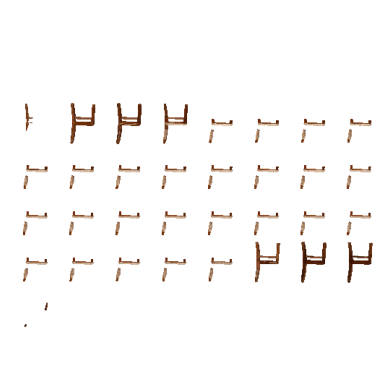

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

grid_size = (8, 8)  # Arrange in a 4x4 grid
texture = gnt.create_flipbook_texture(sdf, colors, grid_size)

# Save as an image
#image = Image.fromarray(texture)
#image.save(r"C:\Users\jelle\Documents\Unity\Geosharpi_Dev\Assets\DrmModels/sdfColor.png")

# Display the image
plt.imshow(texture)
plt.axis("off")
plt.show()

In [4]:
import numpy as np
from PIL import Image

def parse_flipbook_tiles(flipbookImg, grid_size):
    """
    Split a flipbook PNG into separate slices (each tile = one slice).

    Args:
        png_path (str): Path to the flipbook PNG.
        grid_size (tuple): (rows, cols) of the flipbook grid.

    Returns:
        sdf_distances (np.ndarray): (N, H, W) float32
        sdf_colors (np.ndarray): (N, H, W, 3) uint8
    """
    tex_h, tex_w, _ = flipbookImg.shape
    grid_rows, grid_cols = grid_size

    # Compute size of each tile
    H = tex_h // grid_rows
    W = tex_w // grid_cols

    N = grid_rows * grid_cols
    sdf_distances = np.zeros((N, H, W), dtype=np.float32)
    sdf_colors = np.zeros((N, H, W, 3), dtype=np.uint8)

    idx = 0
    for row in range(grid_rows):
        for col in range(grid_cols):
            y, x = row * H, col * W
            frame = flipbookImg[y:y+H, x:x+W, :]

            colors = frame[..., :3]
            alpha = frame[..., 3]

            # Inside/outside from alpha
            dist = np.ones((H, W), dtype=np.float32)
            dist[alpha == 255] = -1.0  # inside

            sdf_colors[idx] = colors
            sdf_distances[idx] = dist
            idx += 1

    return sdf_distances, sdf_colors

# Load image
#img = Image.open(png_path).convert("RGBA")
#flipbook = np.array(img)

sdf_dist, sdf_col = parse_flipbook_tiles(texture, grid_size)

print((sdf_dist.shape, sdf_col.shape))

((64, 64, 64), (64, 64, 64, 3))


## Convex decomposition

The object is segmented 

In [4]:
import coacd

mesh = coacd.Mesh(new_mesh.vertices, new_mesh.faces)
parts = coacd.run_coacd(mesh) # a list of convex hulls.

In [11]:
print(parts[0][1])

[[ 0  1  2]
 [ 0  2  3]
 [ 0  3 12]
 [ 0 12 11]
 [ 0 11 10]
 [ 0 10  9]
 [ 0  9 20]
 [ 0 20 29]
 [ 0 29 22]
 [ 0 22 16]
 [ 0 16 14]
 [ 0 14  4]
 [ 0  4  5]
 [ 0  5  6]
 [ 0  6  1]
 [ 1  7  2]
 [ 1  6  7]
 [ 2  8 19]
 [ 2 19 27]
 [ 2 27 35]
 [ 2 35 46]
 [ 2 46 50]
 [ 2 50 57]
 [ 2 57 67]
 [ 2 67 73]
 [ 2 73 70]
 [ 2 70 75]
 [ 2 75 80]
 [ 2 80 81]
 [ 2 81 76]
 [ 2 76 71]
 [ 2 71 64]
 [ 2 64 54]
 [ 2 54 47]
 [ 2 47 37]
 [ 2 37 28]
 [ 2 28 20]
 [ 2 20  9]
 [ 2  9 10]
 [ 2 10 11]
 [ 2 11 12]
 [ 2 12  3]
 [ 2  7 13]
 [ 2 13  8]
 [ 4 14  5]
 [ 5 15 22]
 [ 5 22 29]
 [ 5 29 38]
 [ 5 38 48]
 [ 5 48 55]
 [ 5 55 66]
 [ 5 66 65]
 [ 5 65 72]
 [ 5 72 78]
 [ 5 78 83]
 [ 5 83 79]
 [ 5 79 74]
 [ 5 74 69]
 [ 5 69 58]
 [ 5 58 51]
 [ 5 51 44]
 [ 5 44 43]
 [ 5 43 32]
 [ 5 32 24]
 [ 5 24 23]
 [ 5 23 17]
 [ 5 17  6]
 [ 5 14 16]
 [ 5 16 15]
 [ 6 17 18]
 [ 6 18 13]
 [ 6 13  7]
 [ 8 13 19]
 [13 21 19]
 [13 18 21]
 [15 16 22]
 [17 23 18]
 [18 23 24]
 [18 24 25]
 [18 25 26]
 [18 26 21]
 [19 21 27]
 [20 28 29]
 [21

In [14]:
def visualize_convex_hulls(parts):
    """
    Visualize a list of convex hulls (coacd.Mesh) in a trimesh.Scene.
    
    Parameters
    ----------
    parts : list of coacd.Mesh
        Each part must have .vertices (Nx3) and .faces (Mx3).
    """
    scene = trimesh.Scene()

    for i, part in enumerate(parts):
        # Convert coacd.Mesh -> trimesh.Trimesh
        mesh = trimesh.Trimesh(vertices=np.array(part[0]),
                               faces=np.array(part[1]),
                               process=False)

        # Assign a random color
        color = np.random.randint(0, 255, size=3)
        mesh.visual.face_colors = np.tile(np.append(color, 255), (len(mesh.faces), 1))

        scene.add_geometry(mesh, node_name=f"part_{i}")

    # Show interactive viewer
    return scene

In [15]:
visualize_convex_hulls(parts).show()

## From Pointcloud

In [6]:
%load_ext autoreload
%autoreload 2
from context import generationtools as gnt
import trimesh

meshPath = r"C:\Users\jelle\Documents\Unity\Geosharpi_Dev\Assets\Output\CompletionChairTest\Mesh[CompletionChair_points - Cloud] (level 8).obj"
voxelResolution = 64 # The resolution of the voxelgrid

# load the mesh
mesh  = trimesh.load(meshPath, force='mesh')
meshName = meshPath.split('\\')[-1][:-4]
savePath = r"K:\Projects\2025-03 Project FWO SB Jelle\7.Data\completionChair"
# convert to SDF
sdf,normalized_mesh = gnt.mesh_to_sdf_tensor(gnt.as_mesh(mesh), voxelResolution, recenter=True, scaledownFactor=1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# OPTIONAL Evaluate the colors in the SDF mesh
marching_mesh = gnt.sdf_to_mesh(sdf, 1/voxelResolution, True)
marching_mesh.show()

In [8]:
import torch
import numpy as np
import time

fixedMeshPath =   savePath + "sdf.obj"
#fixedMeshPath =   meshPath[:-4] + "_sdf.obj"
sdfPath = fixedMeshPath[:-4] + ".npy"
tfPath = fixedMeshPath[:-4] + ".pt"

# output
t0 = time.time()
marching_mesh.export(fixedMeshPath)
np.save(sdfPath, sdf)
# Tensor
shapedData = np.reshape(sdf, [1, 1, 64, 64, 64])
torch.save(torch.from_numpy(shapedData[:,:,:64,:64,:64]), tfPath)

t1 = time.time()
print('It takes %.4f seconds to process' % (t1-t0))
marching_mesh.show()

It takes 0.2150 seconds to process
